In [1]:
import stlrom as stl
from stlrom import Signal, OscillSignalGen

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

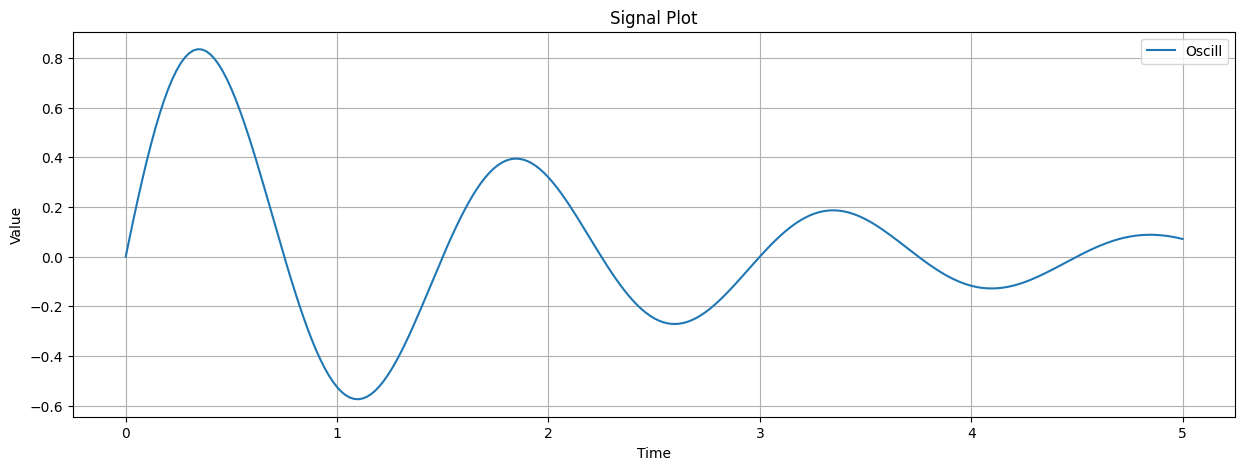

In [10]:
osc_gen  = OscillSignalGen()
sin_sig = osc_gen.get_signal(t0=0, tf=5, dt=0.02, damp=-0.5, period=1.5)
sin_sig.plot(label='Oscill')

In [21]:
driver = stl.STLDriver()
driver.parse_string(
    """
    signal x
    max_local := ev[0,0.1] (x[t]>0)
    min_local := alw[0,0.1] (x[t]>0)
    diff_local := max_local[t]-min_local[t] > 0

    opt_local := diff_local[t] < 0.05
    """)
driver.set_signals([sin_sig])
print(driver)

# STLDriver object defined as
signal x

# With formulas:
diff_local:= max_local[t]-min_local[t] > 0
max_local:= ev_[0,0.1] (x[t] > 0) 
min_local:= alw_[0,0.1] (x[t] > 0) 
opt_local:= diff_local[t] < 0.05

# Data:
# Signal x:
# 251 samples from t0=0 to t_end=5




<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

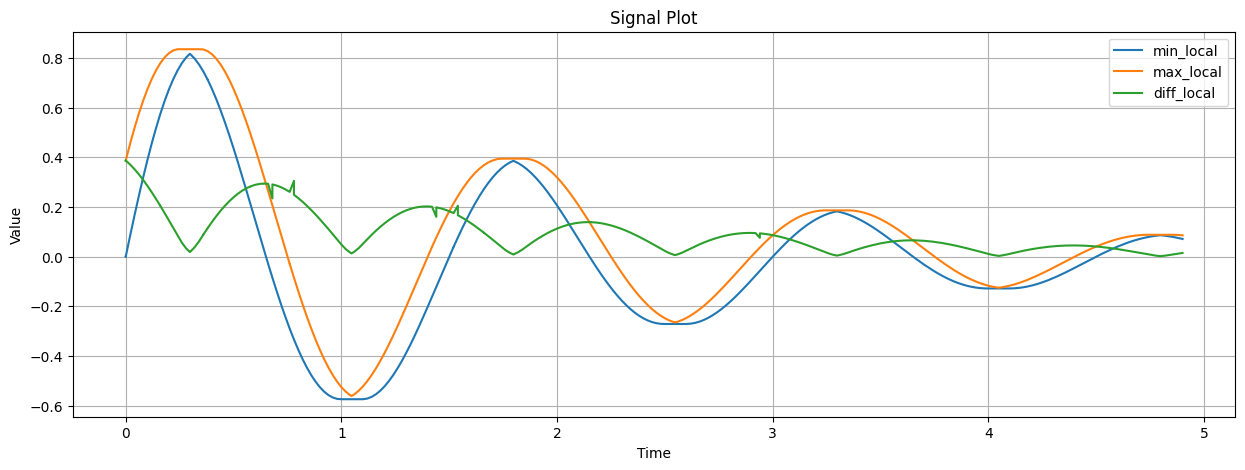

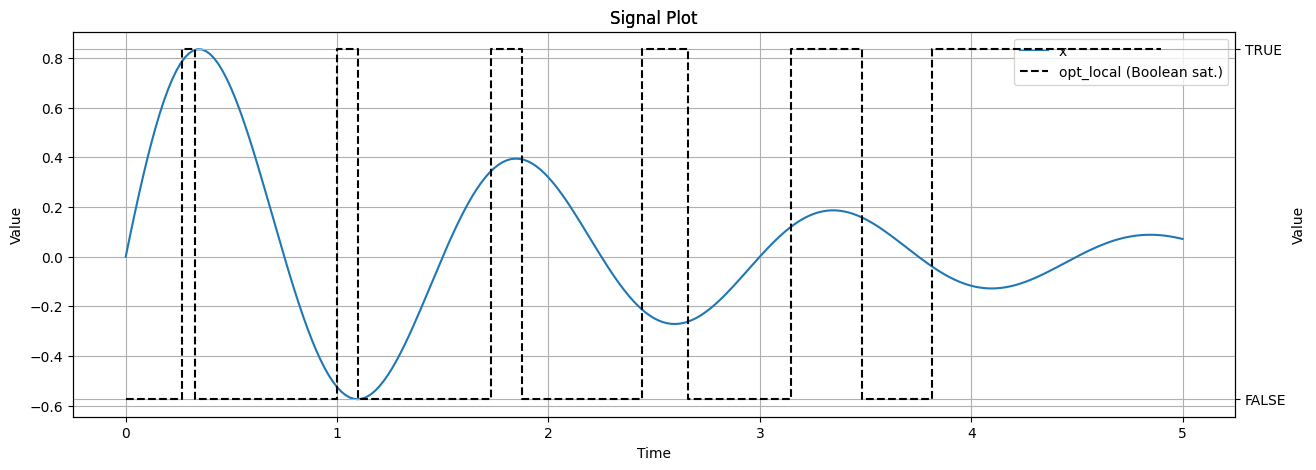

In [23]:
r_min= driver.get_rob_signal('min_local', 0, 4.9)
ax = r_min.plot('min_local')
r_max= driver.get_rob_signal('max_local', 0, 4.9)
r_max.plot(ax=ax, label='max_local')

r_diff = driver.get_rob_signal('diff_local', 0, 4.9)
r_diff.plot('diff_local', ax=ax)

r_opt = driver.get_rob_signal('opt_local', 0,4.9)
ax_opt = sin_sig.plot('x')
r_opt.plot('opt_local',  ax=ax_opt, plot_sat=True, plot_rob=False)
